In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv("C:/Users/cash/Downloads/bank_cleaned.csv",sep=",",index_col=0)

La base de données "bank_cleaned.csv" contient des données sur les campagnes de marketing direct (appels téléphoniques) d'une institution bancaire portugaise. Les données ont été nettoyées et préparées pour l'analyse.

Les caractéristiques (variables explicatives) enregistrées pour chaque client sont les suivantes :

-age : l'âge du client (variable numérique)

-job : la profession du client (variable catégorielle)

-marital : l'état matrimonial du client (variable catégorielle)

-education : le niveau d'éducation du client (variable catégorielle)

-default : indique si le client a un crédit en défaut ou non (variable catégorielle)

-balance : le solde du compte du client (variable numérique)

-housing : indique si le client a un prêt immobilier ou non (variable catégorielle)

-loan : indique si le client a un prêt personnel ou non (variable catégorielle)

-day : le jour du mois de la dernière communication avec le client (variable numérique)

-month : le mois de la dernière communication avec le client (variable catégorielle)

-duration : la durée de la dernière communication avec le client, en secondes (variable numérique)

-campaign : le nombre de contacts effectués au cours de cette campagne pour ce client (variable numérique)

-pdays : le nombre de jours écoulés depuis le dernier contact avec le client lors d'une campagne précédente (variable numérique ; 999 signifie que le client n'a pas été contacté précédemment)

-previous : le nombre de contacts effectués avant cette campagne pour ce client (variable numérique)

-poutcome : le résultat de la précédente campagne marketing (variable catégorielle)

-response : la réponse du client à la dernière campagne marketing (variable catégorielle)

-response_binary : la réponse du client à la dernière campagne marketing, encodée en binaire (0 = pas intéressé, 1 = intéressé) (variable numérique)

La variable cible est :

response_binary : a-t-il souscrit un dépôt à terme ? (variable catégorielle)
Les données ont été préparées pour l'analyse en remplaçant les valeurs manquantes par des valeurs médianes ou moyennes, en convertissant les variables catégorielles en variables binaires, et en supprimant les variables inutiles ou redondantes.

La base de données contient 4521 entrées (lignes) et 9 caractéristiques (colonnes).

In [4]:
data.describe(include="all")

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,poutcome,response,response_binary
count,40841.000000,40841,40841,40841,40841,40841.000000,40841,40841,40841.000000,40841,40841.000000,40841.000000,40841.000000,40841.000000,40841,40841,40841.000000
unique,NaN,12,3,3,2,NaN,2,2,NaN,12,NaN,NaN,NaN,NaN,3,2,NaN
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,NaN,may,NaN,NaN,NaN,NaN,unknown,no,NaN
freq,NaN,8805,24641,21933,40078,NaN,22820,34042,NaN,12496,NaN,NaN,NaN,NaN,34802,36202,NaN
mean,40.790676,NaN,NaN,NaN,NaN,1073.981807,NaN,NaN,15.863666,NaN,4.308949,2.774149,32.248304,0.436791,NaN,NaN,0.113587
std,10.475473,NaN,NaN,NaN,NaN,1712.556186,NaN,NaN,8.313608,NaN,4.305823,3.104177,90.738402,1.572342,NaN,NaN,0.317313
min,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,1.000000,NaN,0.100000,1.000000,-1.000000,0.000000,NaN,NaN,0.000000
25%,33.000000,NaN,NaN,NaN,NaN,64.000000,NaN,NaN,8.000000,NaN,1.730000,1.000000,-1.000000,0.000000,NaN,NaN,0.000000
50%,39.000000,NaN,NaN,NaN,NaN,421.000000,NaN,NaN,16.000000,NaN,3.000000,2.000000,-1.000000,0.000000,NaN,NaN,0.000000
75%,48.000000,NaN,NaN,NaN,NaN,1333.000000,NaN,NaN,21.000000,NaN,5.300000,3.000000,-1.000000,0.000000,NaN,NaN,0.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40841 entries, 0 to 45209
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              40841 non-null  int64  
 1   job              40841 non-null  object 
 2   marital          40841 non-null  object 
 3   education        40841 non-null  object 
 4   default          40841 non-null  object 
 5   balance          40841 non-null  int64  
 6   housing          40841 non-null  object 
 7   loan             40841 non-null  object 
 8   day              40841 non-null  int64  
 9   month            40841 non-null  object 
 10  duration         40841 non-null  float64
 11  campaign         40841 non-null  int64  
 12  pdays            40841 non-null  int64  
 13  previous         40841 non-null  int64  
 14  poutcome         40841 non-null  object 
 15  response         40841 non-null  object 
 16  response_binary  40841 non-null  int64  
dtypes: float64(1), in

In [20]:
data.head()

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,poutcome,response,response_binary
0,58,management,married,tertiary,no,2143,yes,no,5,may,4.35,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,5,may,2.52,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,1.27,1,-1,0,unknown,no,0
5,35,management,married,tertiary,no,231,yes,no,5,may,2.32,1,-1,0,unknown,no,0
6,28,management,single,tertiary,no,447,yes,yes,5,may,3.62,1,-1,0,unknown,no,0


In [6]:
data.isnull().sum()


age                0
job                0
marital            0
education          0
default            0
balance            0
housing            0
loan               0
day                0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome           0
response           0
response_binary    0
dtype: int64

In [22]:
data["response_binary"].value_counts()

response_binary
0    36202
1     4639
Name: count, dtype: int64

<Axes: >

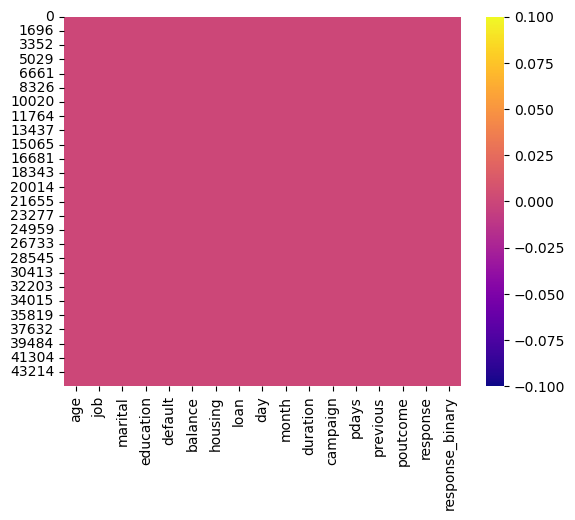

In [23]:
sns.heatmap(data.isnull(),cmap="plasma")

Aucune valeur manquante dans la base de données

In [7]:
from sklearn.compose import *


In [8]:
categorical_features=make_column_selector(dtype_exclude=np.number)
categorical_features(data)


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'month',
 'poutcome',
 'response']

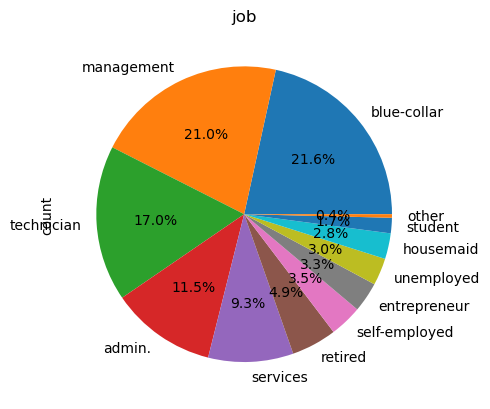

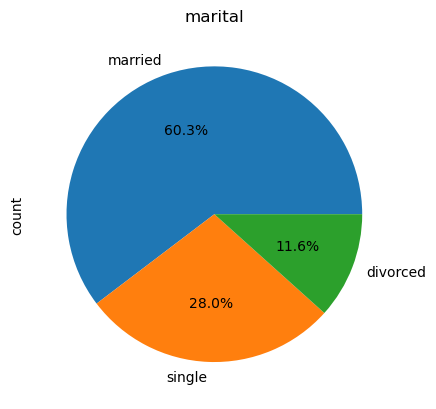

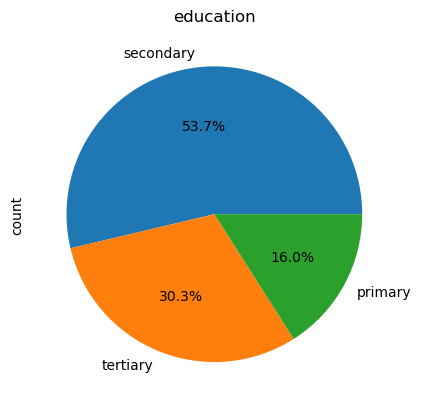

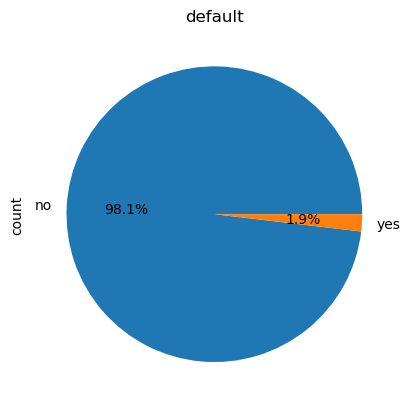

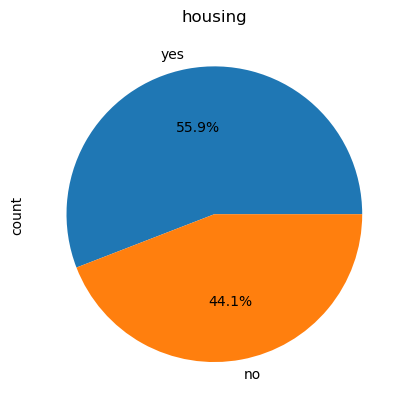

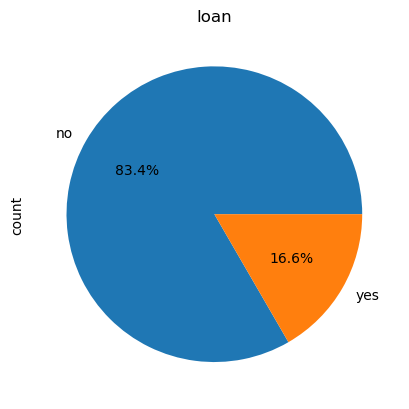

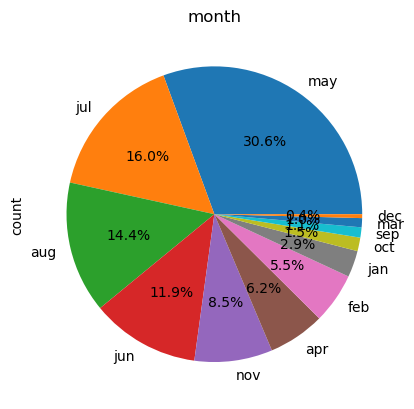

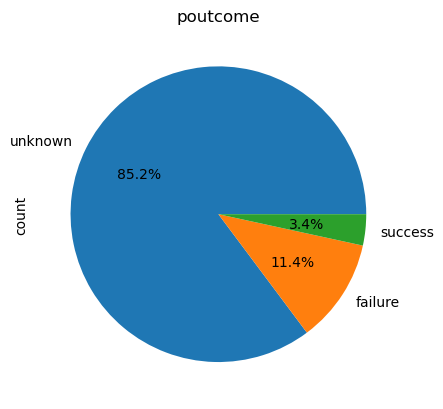

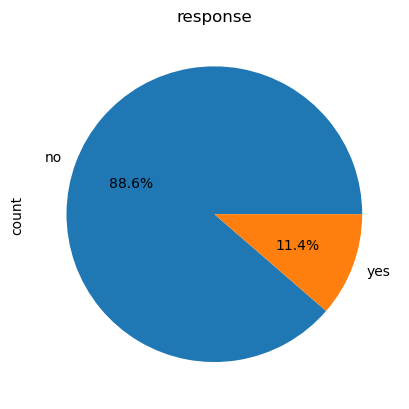

In [9]:
for var in categorical_features(data):
    plt.figure()
    data[var].value_counts().plot(kind="pie",autopct='%1.1f%%')
    plt.title(var)
    plt.show()

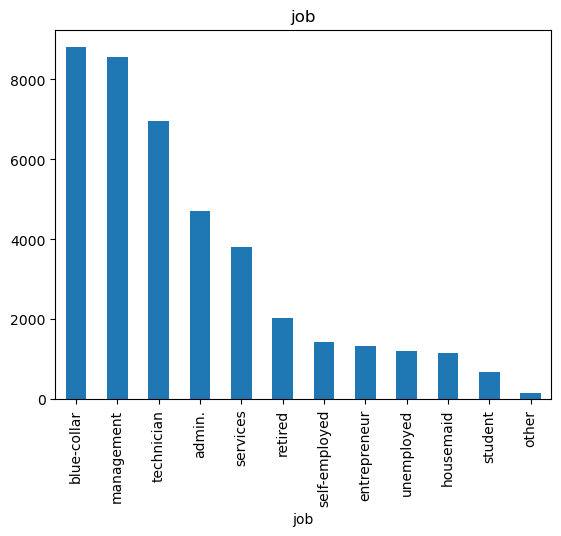

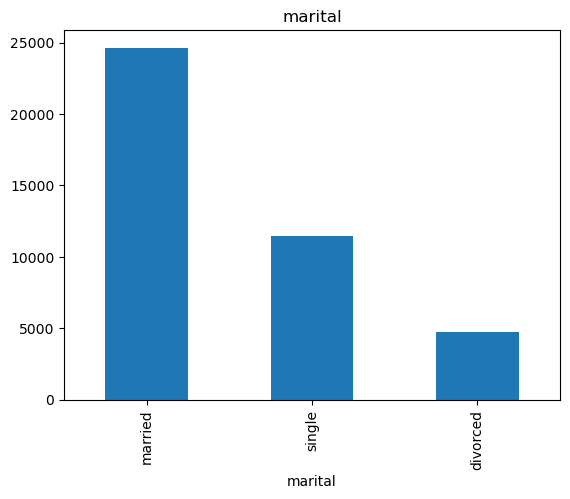

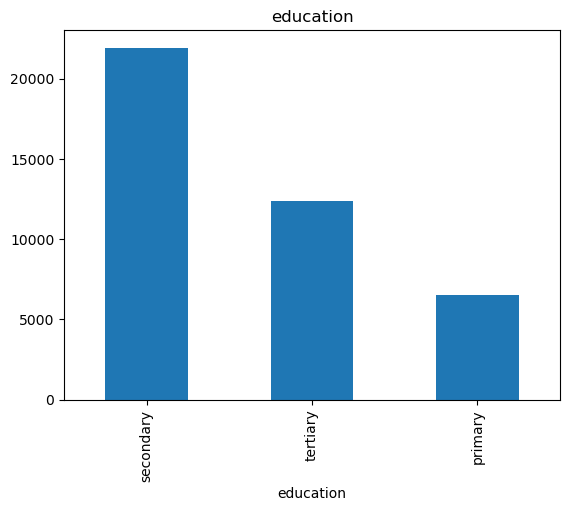

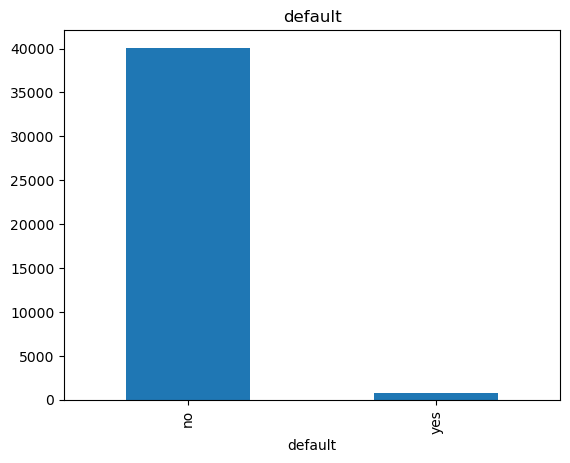

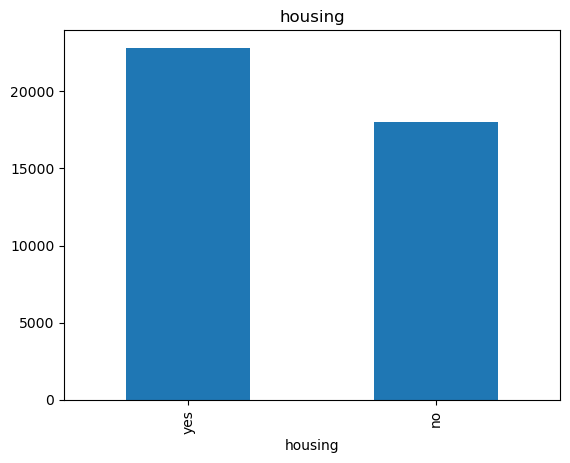

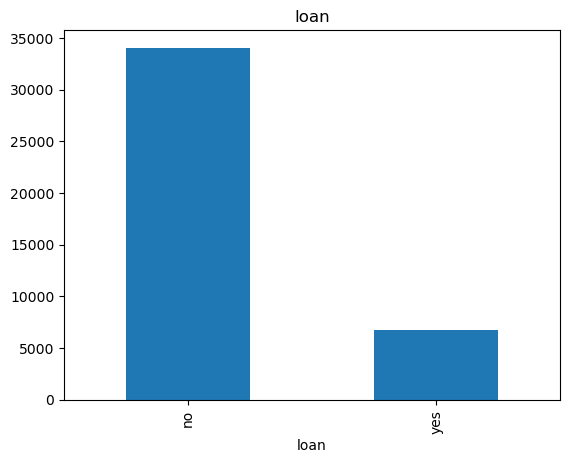

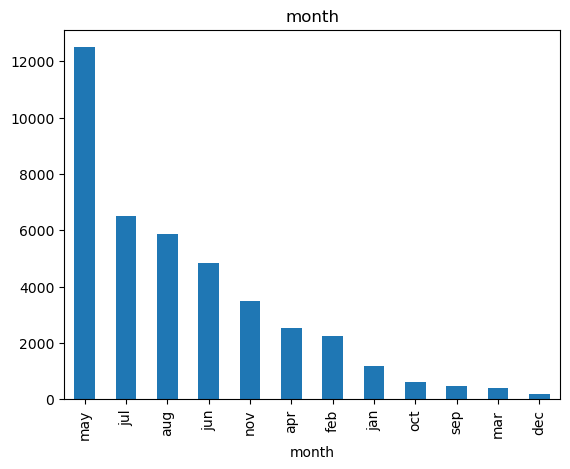

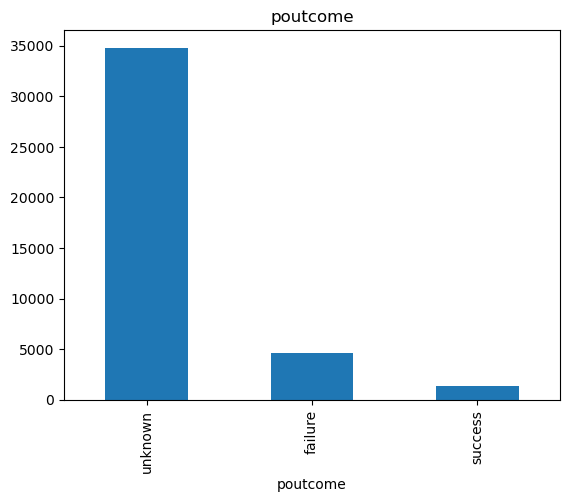

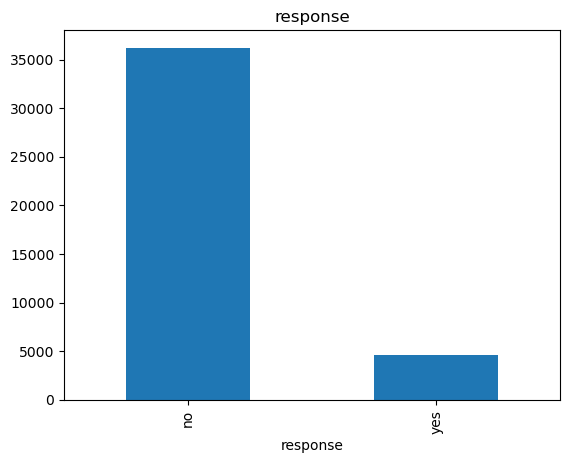

In [27]:

for var in categorical_features(data):
    plt.figure()
    data[var].value_counts().plot(kind='bar')
    plt.title(var)
    plt.show()

La variable est réponse a des modalités déséquilibrées avec 88,6% de réponse non et 11,4% de réponse oui.

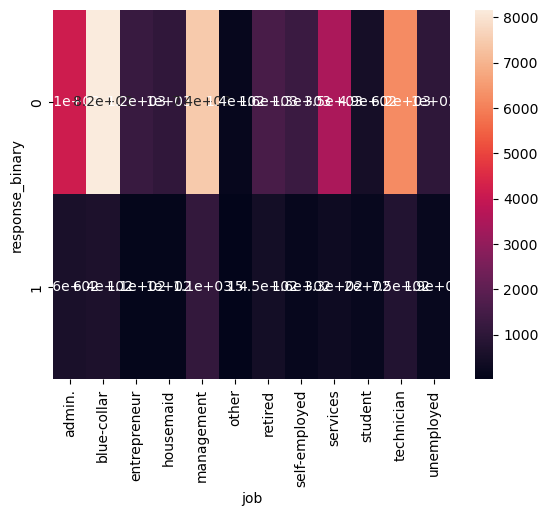

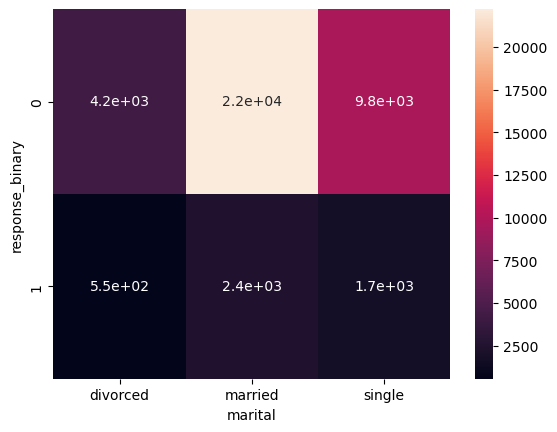

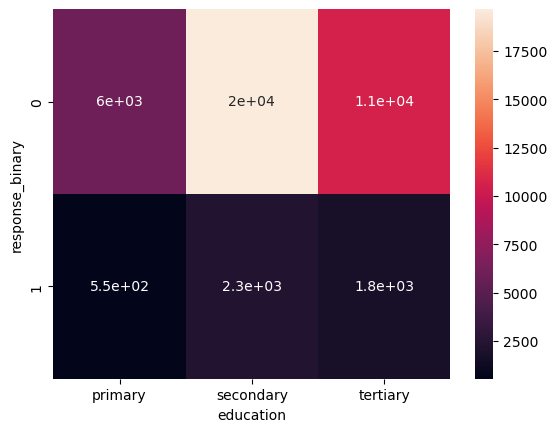

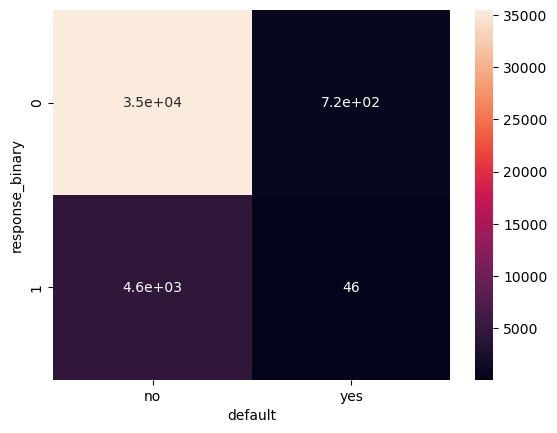

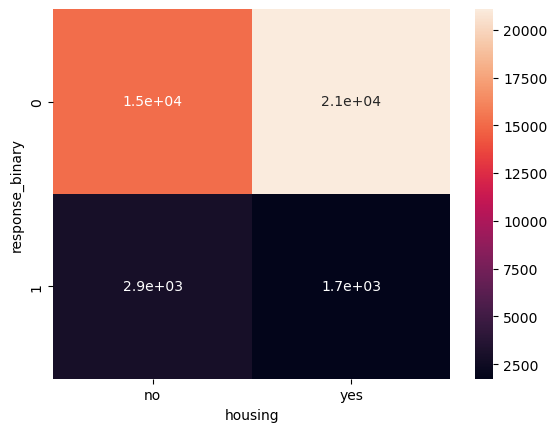

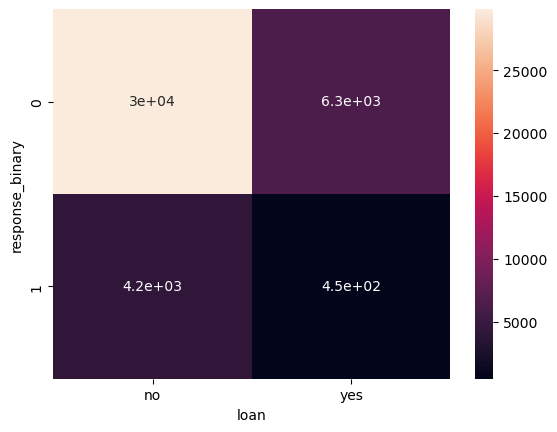

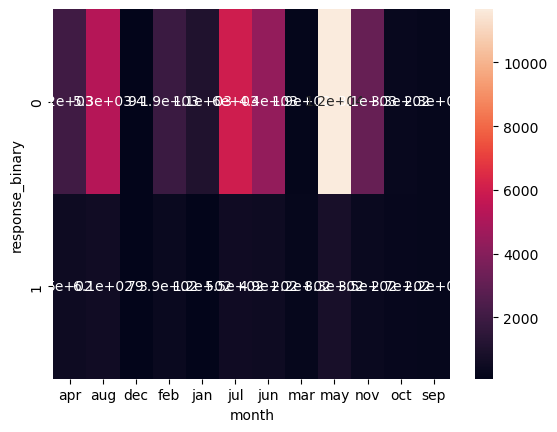

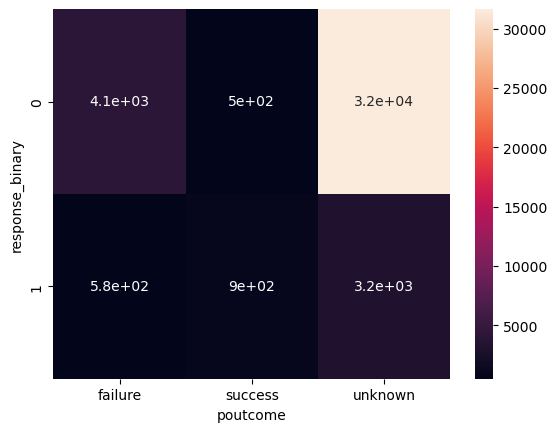

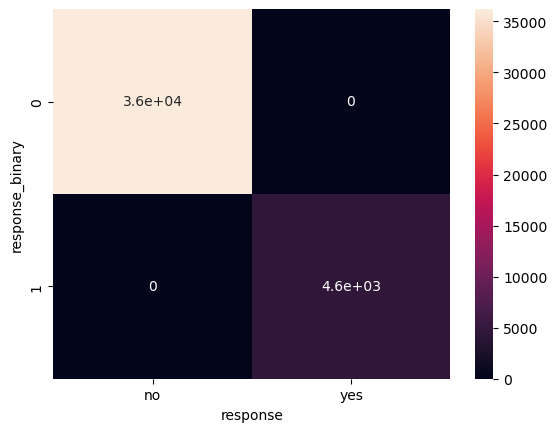

In [10]:
features=data.drop(['response_binary'],axis=1)
pd.crosstab(data['response_binary'],data["response"])
for var in features.select_dtypes("object"):
    plt.figure()
    sns.heatmap(pd.crosstab(data["response_binary"],data[var]),annot=True)

In [11]:
numerical_features=make_column_selector(dtype_include=np.number)


In [30]:
numerical_features(data.drop(["response_binary"],axis=1))

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

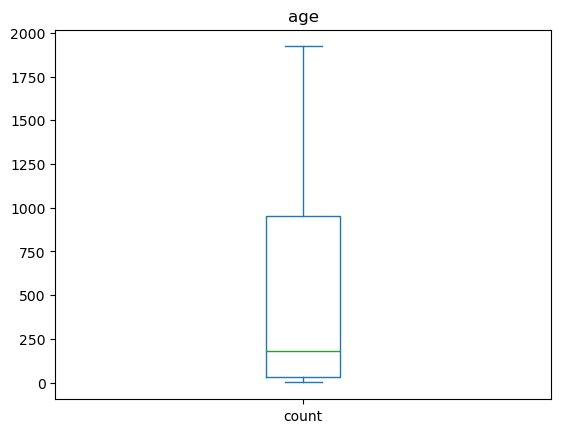

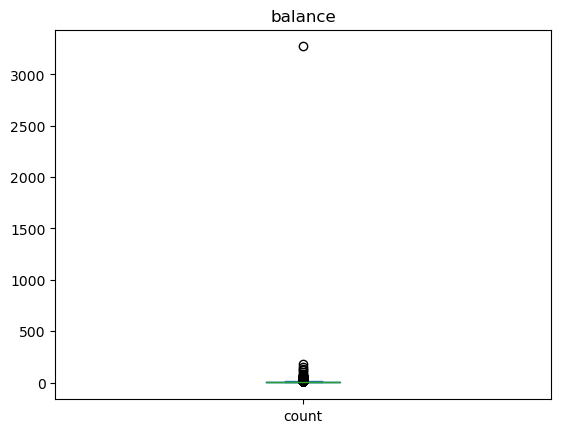

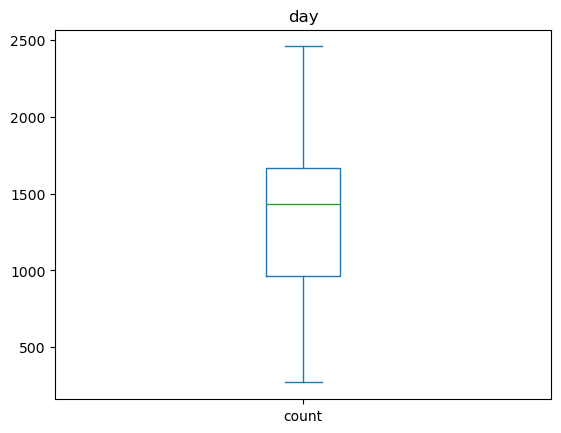

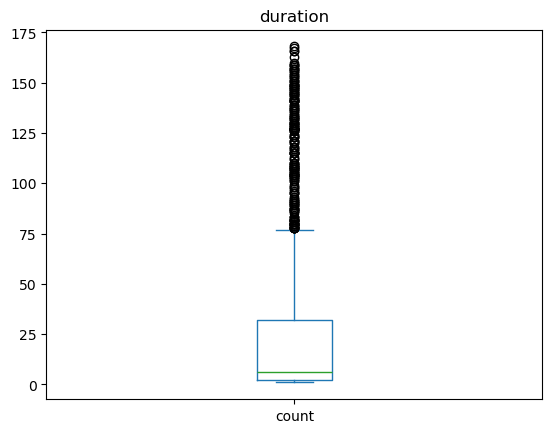

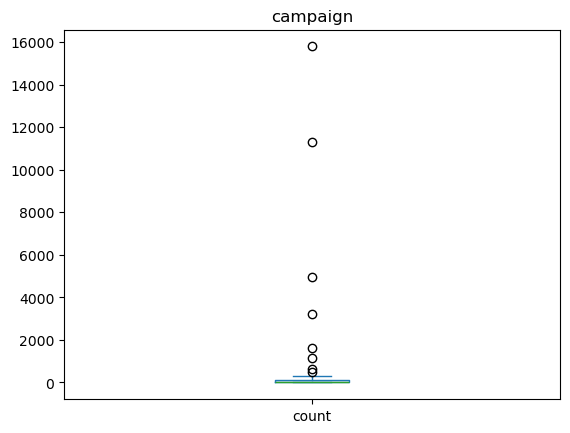

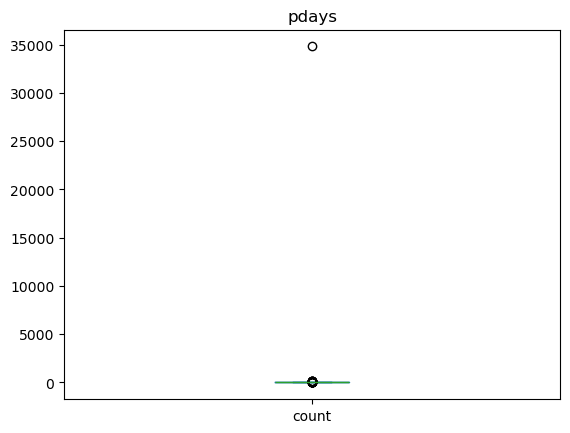

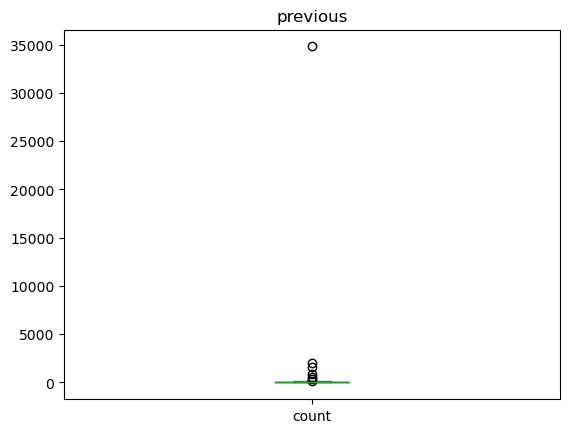

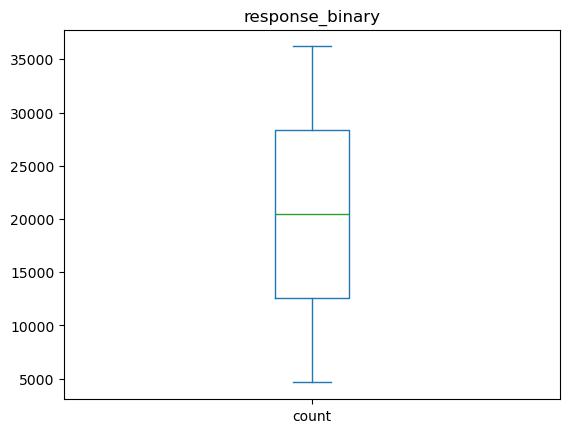

In [31]:
for var in numerical_features(data):
    plt.figure()
    data[var].value_counts().plot(kind="box")
    plt.title(var)
    plt.show()

In [ ]:
 sns.pairplot(data,hue='response_binary')

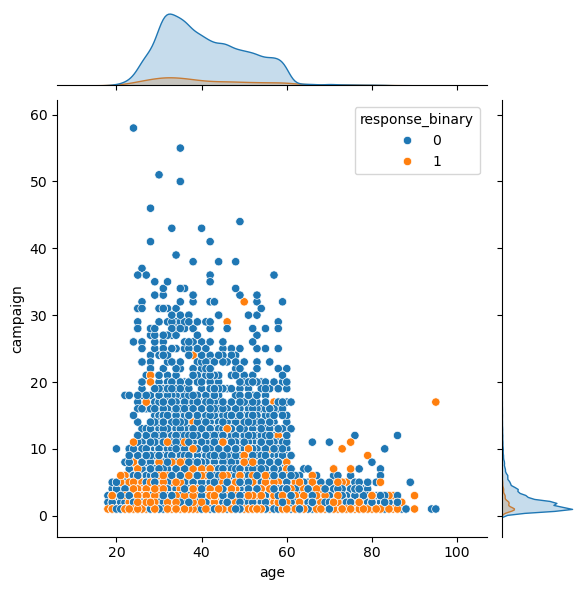

In [33]:
sns.jointplot(data=data,x='age',y='campaign',hue="response_binary")

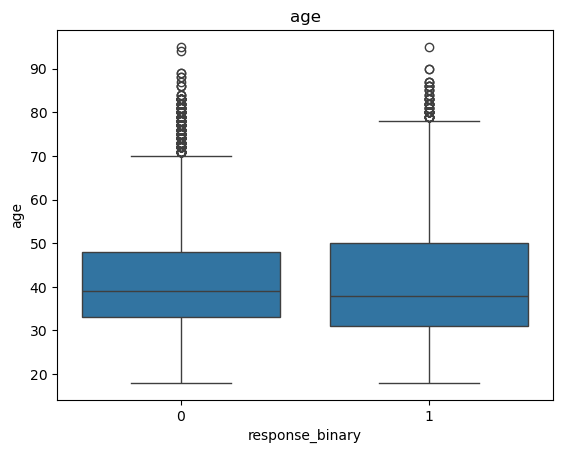

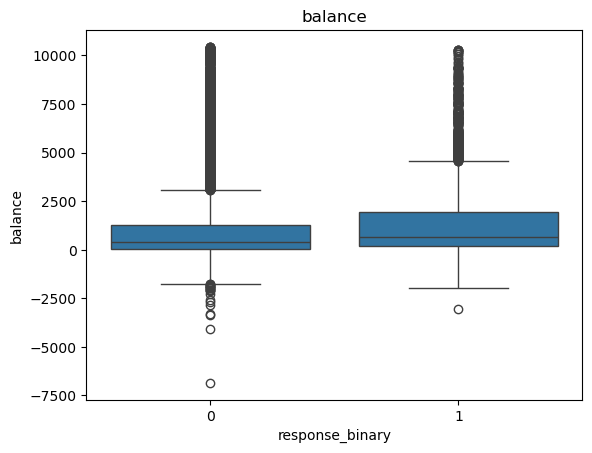

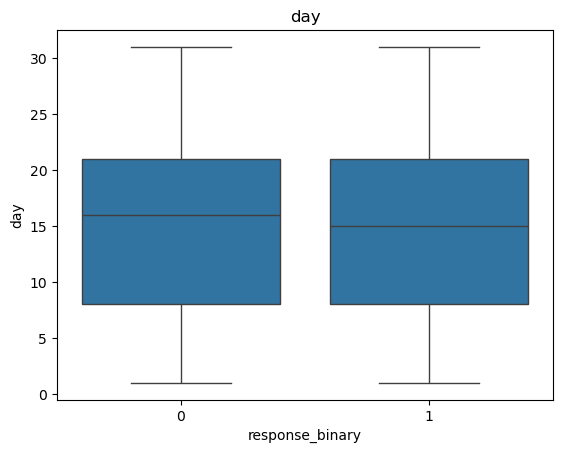

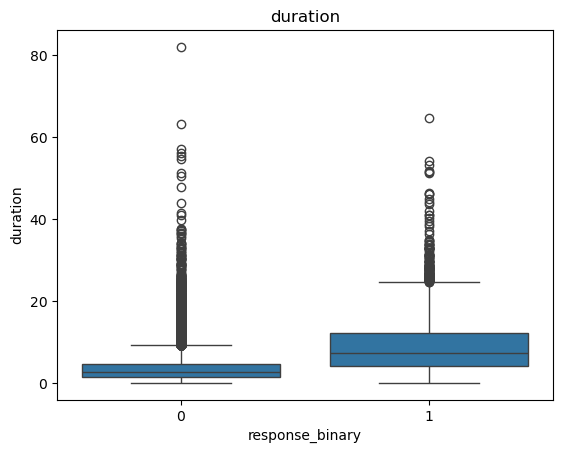

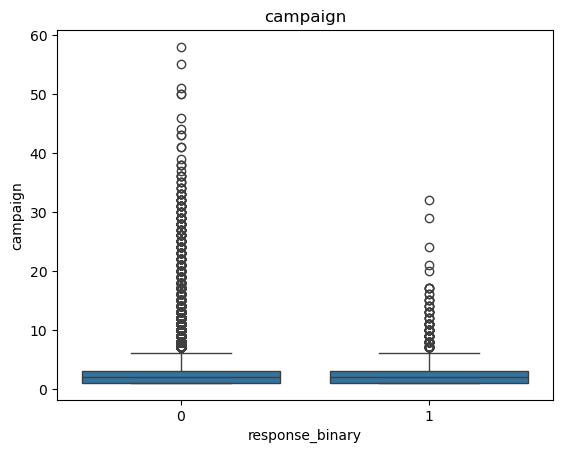

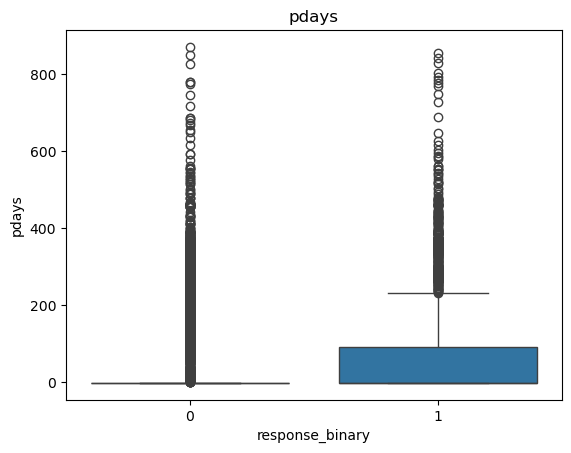

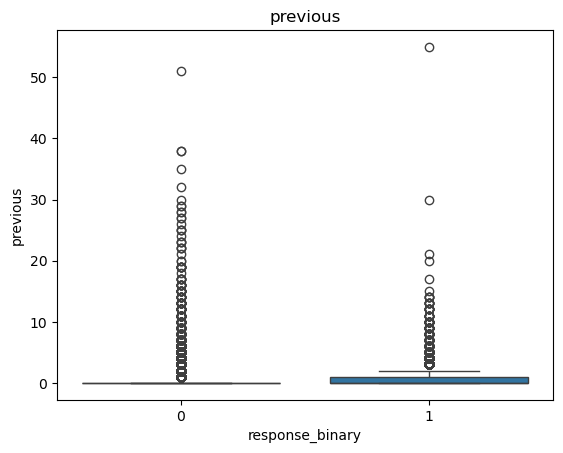

In [34]:
for var in numerical_features(data.drop(["response_binary"],axis=1)):
    plt.figure()
    sns.boxplot(data=data,x="response_binary",y=var)
    plt.title(var)
    plt.show()
   

C:\Users\cash\AppData\Local\Temp\ipykernel_18796\3858066067.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[var])


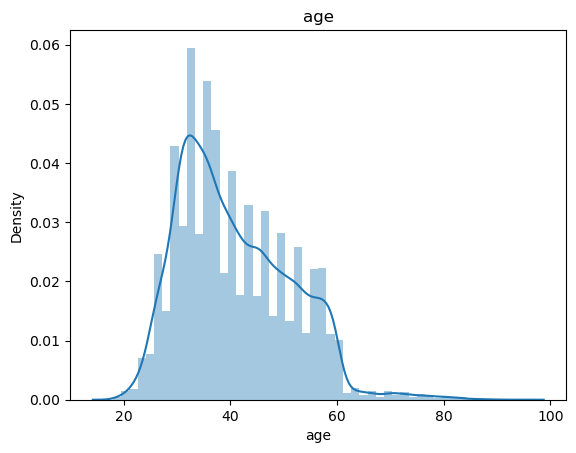

C:\Users\cash\AppData\Local\Temp\ipykernel_18796\3858066067.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[var])


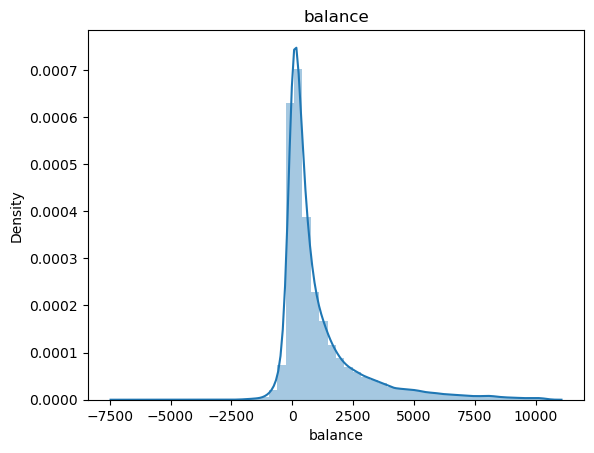

C:\Users\cash\AppData\Local\Temp\ipykernel_18796\3858066067.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[var])


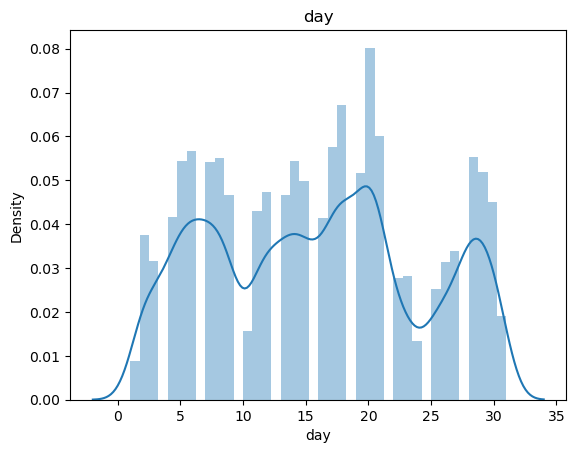

C:\Users\cash\AppData\Local\Temp\ipykernel_18796\3858066067.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[var])


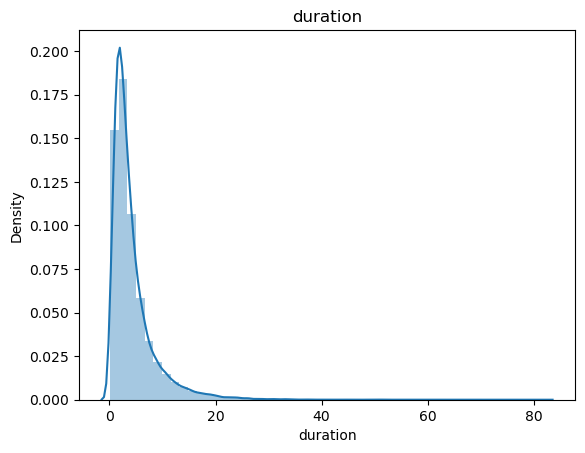

C:\Users\cash\AppData\Local\Temp\ipykernel_18796\3858066067.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[var])


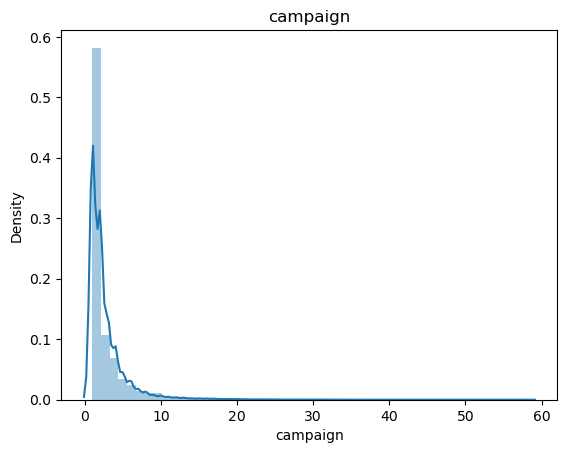

C:\Users\cash\AppData\Local\Temp\ipykernel_18796\3858066067.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[var])


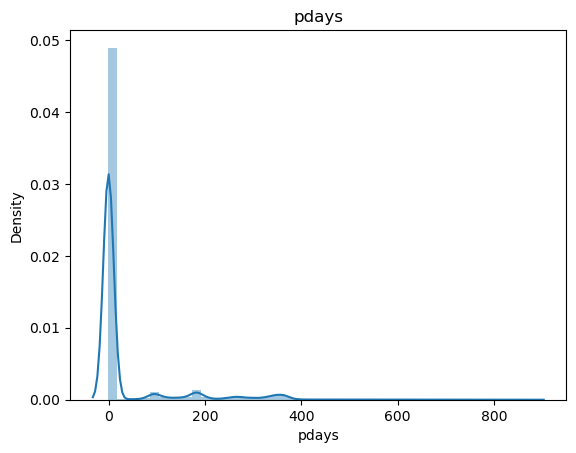

C:\Users\cash\AppData\Local\Temp\ipykernel_18796\3858066067.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[var])


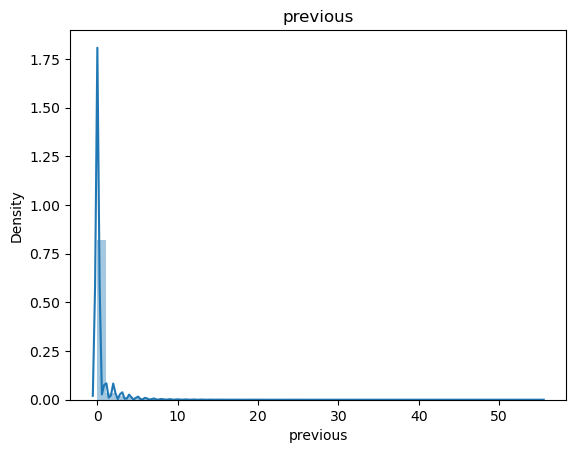

In [35]:
for var in numerical_features(data.drop(["response_binary"],axis=1)):
    plt.figure()
    sns.distplot(data[var])
    plt.title(var)
    plt.show()

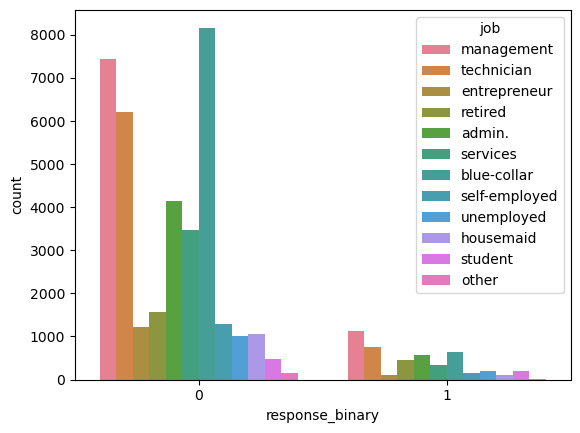

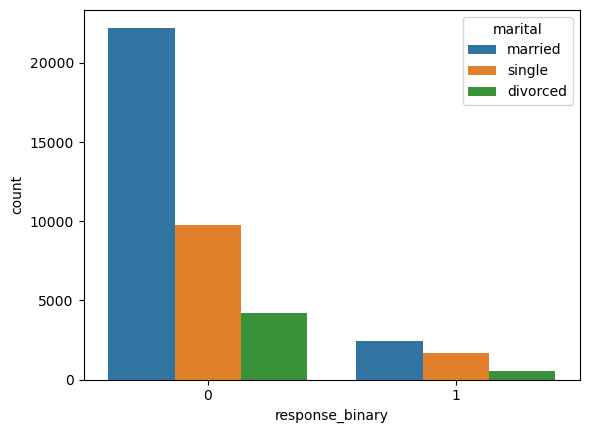

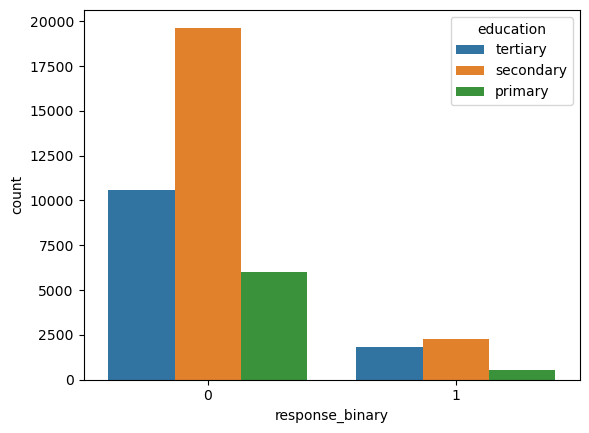

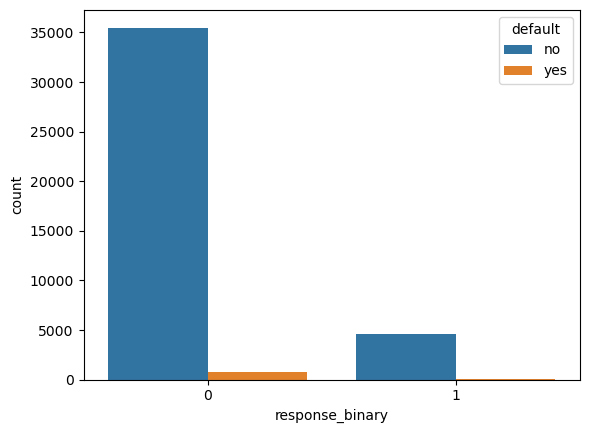

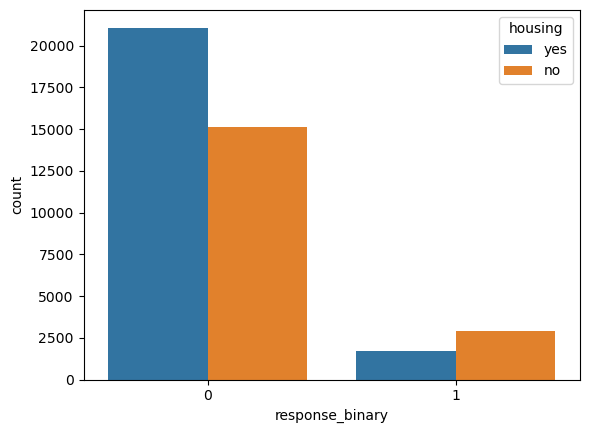

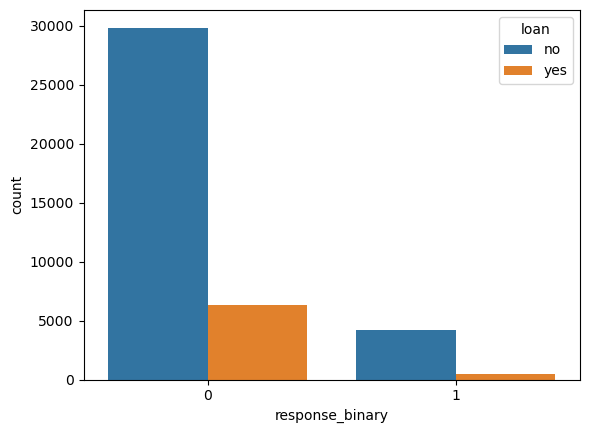

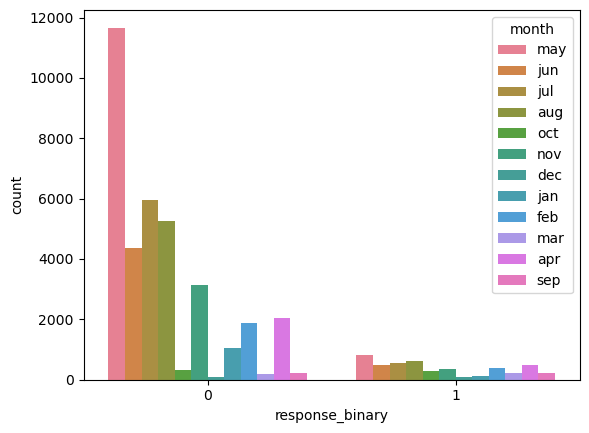

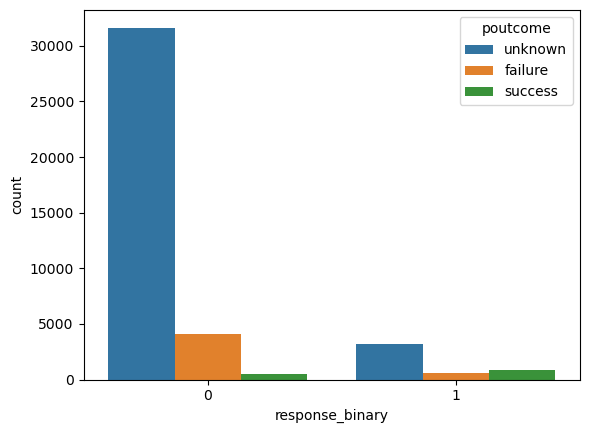

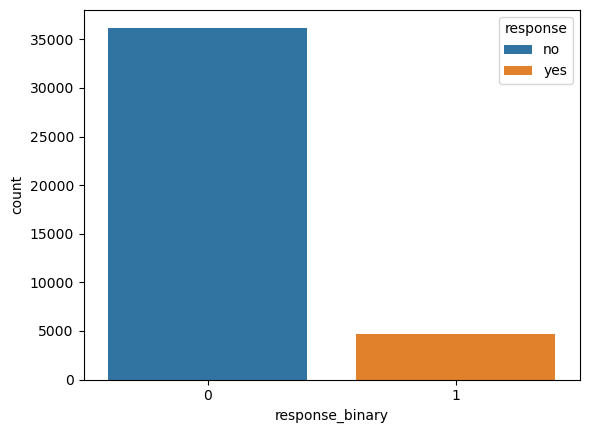

In [36]:
for var in categorical_features(data.drop(["response_binary"],axis=1)):
    plt.figure()
    sns.countplot(data=data,x="response_binary",hue=var)


In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40841 entries, 0 to 45209
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              40841 non-null  int64  
 1   job              40841 non-null  object 
 2   marital          40841 non-null  object 
 3   education        40841 non-null  object 
 4   default          40841 non-null  object 
 5   balance          40841 non-null  int64  
 6   housing          40841 non-null  object 
 7   loan             40841 non-null  object 
 8   day              40841 non-null  int64  
 9   month            40841 non-null  object 
 10  duration         40841 non-null  float64
 11  campaign         40841 non-null  int64  
 12  pdays            40841 non-null  int64  
 13  previous         40841 non-null  int64  
 14  poutcome         40841 non-null  object 
 15  response         40841 non-null  object 
 16  response_binary  40841 non-null  int64  
dtypes: float64(1), in

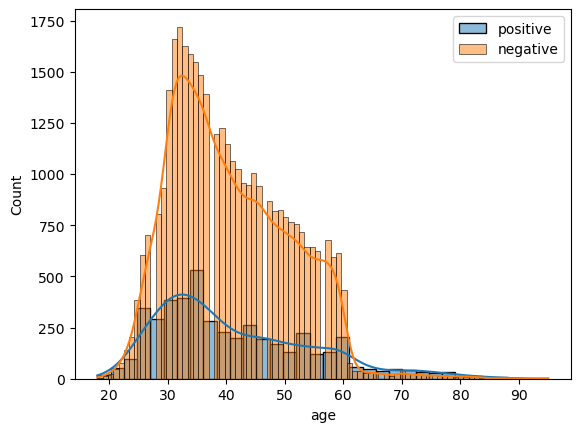

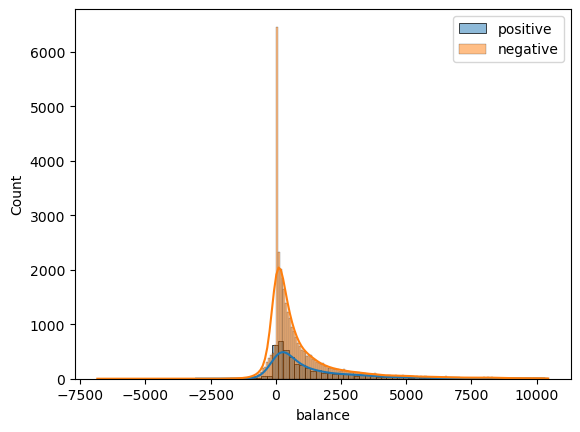

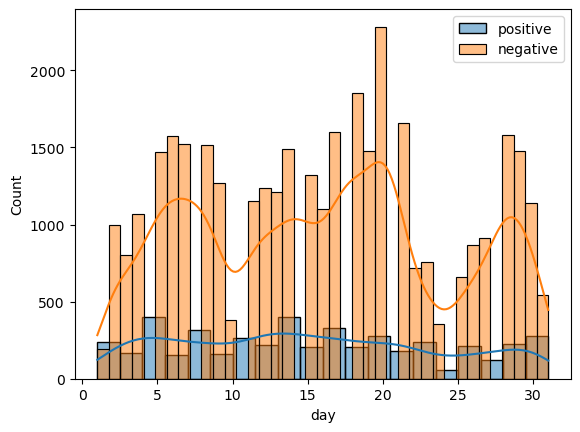

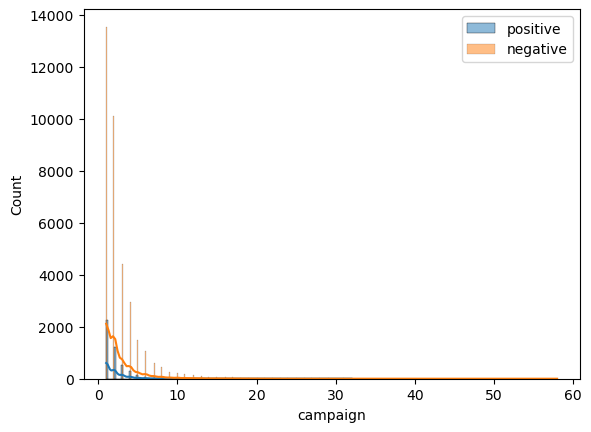

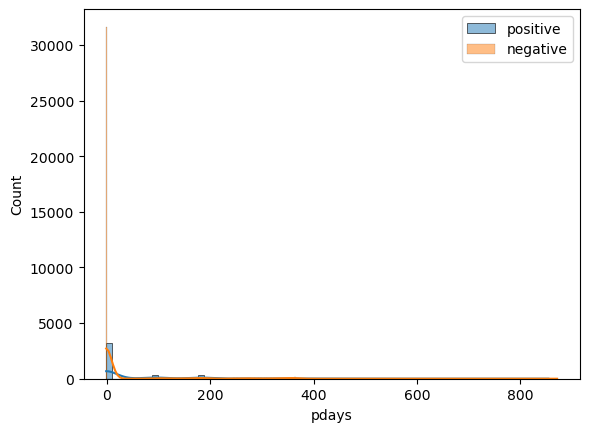

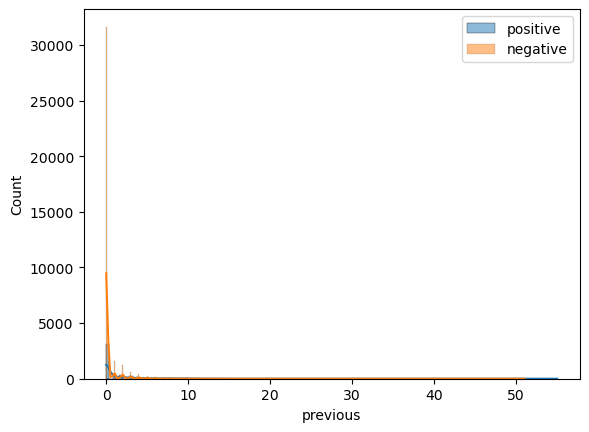

In [38]:
positive_data=data[data["response_binary"]==1]
negative_data=data[data["response_binary"]==0]
features=data.drop(['response_binary'],axis=1)
for var in features.select_dtypes('int','float'):
    plt.figure()
    sns.histplot(positive_data[var],kde=True, label="positive")
    sns.histplot(negative_data[var],kde=True, label="negative")
    plt.legend()

Preprocessing

In [39]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import make_pipeline 
from sklearn.model_selection import *
from sklearn.compose import *

In [40]:
X=data.drop(["response_binary","response"],axis=1)
y=data["response_binary"]


In [41]:
#X=pd.get_dummies(X,drop_first=True)
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2,random_state=100)

Construction d'une pipeline de prétraitement de données


In [42]:
numerical_features=make_column_selector(dtype_include=np.number)
categorical_features=make_column_selector(dtype_exclude=np.number)
numerical_pipeline=make_pipeline(StandardScaler())
categorical_pipeline=make_pipeline(OneHotEncoder(drop="first", handle_unknown="ignore"))
preprocessor=make_column_transformer((numerical_pipeline,numerical_features),(categorical_pipeline,categorical_features))

Construction du modèle de régression logistique

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
#numerical_features=make_column_selector(dtype_include=np.number)
#numerical_pipeline=make_pipeline(StandardScaler())
#model_logistic=make_pipeline(preprocessor,LogisticRegression())
#proprocessor=make_column_transformer((numerical_pipeline,numerical_features))
model_logistic=make_pipeline(preprocessor,LogisticRegression())
model_logistic.fit(X_train,y_train)


,steps,"[('columntransformer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
print('Train_score:',model_logistic.score(X_train,y_train))
print('Test_score:',model_logistic.score(X_test,y_test))

Train_score: 0.9049032810969637
Test_score: 0.9042722487452565


In [45]:
y_pred=model_logistic.predict(X_test)

Construction d'un arbre de décision et de méthode ensembliste (Random_forest, XGBoost): Etant donné la présence d'un grand nombre de variables catégorielles dans nos features, les arbres de décision ou les méthodes ensemblistes basées sur les arbres de décisions peuvent s'avérer efficace, voyons cela !

In [46]:
from sklearn.tree import DecisionTreeClassifier
model_tree=make_pipeline(preprocessor,DecisionTreeClassifier(random_state=0))


In [47]:
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier
model_ada=make_pipeline(preprocessor,AdaBoostClassifier(random_state=0))
model_ada.fit(X_train,y_train)
model_Rf=make_pipeline(preprocessor,RandomForestClassifier(random_state=0))
model_Rf.fit(X_train,y_train)
print('Train_score_tree:',model_tree.score(X_train,y_train))
print('Test_score_tree:',model_tree.score(X_test,y_test))
print('Train_score_ada:',model_ada.score(X_train,y_train))
print('Test_score_ada:',model_ada.score(X_test,y_test))
print('Train_score_Rf:',model_Rf.score(X_train,y_train))
print('Test_score_Rf:',model_Rf.score(X_test,y_test))

NotFittedError: Pipeline is not fitted yet.

In [ ]:
model_tree.fit(X_train,y_train)

In [ ]:
from sklearn.metrics import *
print(classification_report(y_test,y_pred))

La variable cible response_binary : a-t-il souscrit un dépôt à terme ?
Classe minoriatiaire=1
-Régression logistique:Le modèle prédit environ 64% de 1 comme le montre la précision, mais parmi les 64 % prédit comme étant appartenant à la catégorie 1, il y n'a qu'environ 33% qui appartiennent réellement à cette classe


In [ ]:
print(confusion_matrix(y_test,y_pred))

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model_logistic,X_test,y_test)

In [ ]:
import statsmodels.api as sm

In [ ]:
X_transformed=preprocessor.fit_transform(X_train)
X_transformed=sm.add_constant(X_transformed)

In [ ]:
model=sm.Logit(y_train,X_transformed)
result=model.fit()
result.summary()

Procédure d'évaluation des différents modèles

In [ ]:

from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import learning_curve
def evaluation(model):
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    print(confusion_matrix(y_test,y_pred))
    print(classification_report(y_test,y_pred))
    N,train_score,val_score=learning_curve(model,X_train,y_train, cv=4,train_sizes=np.linspace(0.1,1,10))
    plt.figure(figsize=(12,8))
    plt.plot(N,train_score.mean(axis=1),label='Train score')
    plt.plot(N,val_score.mean(axis=1),label='Validation_score')
    plt.legend()
    RocCurveDisplay.from_estimator(model,X_test,y_test)

In [ ]:
evaluation(model_logistic)

In [ ]:
evaluation(model_tree)

L'arbre à de meilleur preformance sur la prédiction de la classe minoritaire que la régression logistique mais surapprend. On pourrait l'optimiser afin d'obtenir de meilleur performance sur sa capacité à généraliser.

In [ ]:
evaluation(model_ada)

In [ ]:
evaluation(model_Rf)

Courbe de précision recall

In [ ]:

from sklearn.metrics import precision_recall_curve
precision,recall, seuil=precision_recall_curve(y_test,model_ada.decision_function(X_test))
plt.plot(seuil,precision[:-1],label="précision")
plt.plot(seuil,recall[:-1],label="Recall")
plt.legend()

In [ ]:
def model_final(model, X, threshold=0):
    return model.decision_function(X) > threshold

In [ ]:
y_pred = model_final(model_logistic, X_test, threshold=-1)

In [ ]:
from sklearn.metrics import recall_score
#f1_score(y_test, y_pred)
recall_score(y_test, y_pred)

Optimisation de l'abre de décision

In [ ]:
from sklearn.model_selection import GridSearchCV
